## ml_v15 : ingredient_count 피처 추가
* 베이스라인: ml_v14 Test AUC 0.7852
* 신규 피처: ingredient_count (성분 총 개수 — 포뮬레이션 복잡도 proxy)
* 데이터: ml_AmazonSephoraUlta_v2.csv

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedKFold, cross_validate, RandomizedSearchCV, GridSearchCV
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from lightgbm import LGBMClassifier
from scipy.stats import randint, uniform
import re, warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 11

DATA_PATH = r"C:\workspace\finalproject\data\ml_AmazonSephoraUlta_v2.csv"
df_all = pd.read_csv(DATA_PATH, encoding='cp949', low_memory=False)

df_all['카테고리(중)'] = df_all['카테고리(중)'].str.lower().str.strip()

print(f"전체: {len(df_all)}개")
print(f"플랫폼별:\n{df_all['store_id'].str.split('_').str[0].value_counts().to_string()}")
print(f"\n리뷰수 있음: {df_all['리뷰수'].notna().sum()}개")
print(f"평점 있음:   {df_all['평점'].notna().sum()}개")
print(f"\ntarget_category 분포:\n{df_all['target_category'].value_counts().to_string()}")

전체: 5964개
플랫폼별:
store_id
amazon     2560
sephora    1802
ulta       1602

리뷰수 있음: 5929개
평점 있음:   5929개

target_category 분포:
target_category
skincare     3963
cleansing    1037
suncare       551
masks         413


In [22]:
# ── Y값: 정규화(평점) × 정규화(log_review_count) → 극단 30% 이진분류
# PCA 제거 근거: KMO=0.0001(부적합), Bartlett p=0.55(비유의), 음의 상관
# 복합 지수 = 질(평점) × 양(리뷰수) → 두 변수의 특성을 명시적으로 반영
df_y = df_all[
    df_all['리뷰수'].notna() &
    df_all['평점'].notna() &
    (df_all['평점'] <= 5)
].copy()

log_review             = np.log1p(df_y['리뷰수'])
df_y['y_rating_norm']  = df_y['평점'] / 5.0
df_y['y_review_norm']  = log_review / log_review.max()
df_y['y_composite']    = df_y['y_rating_norm'] * df_y['y_review_norm']

th_lo = df_y['y_composite'].quantile(0.30)
th_hi = df_y['y_composite'].quantile(0.70)
mask  = (df_y['y_composite'] <= th_lo) | (df_y['y_composite'] >= th_hi)
df_y  = df_y[mask].copy()
df_y['target'] = (df_y['y_composite'] >= th_hi).astype(int)

print(f"복합 지수 분포:")
print(f"  비인기 (하위 30%) 임계값: {th_lo:.4f}")
print(f"  인기   (상위| 30%) 임계값: {th_hi:.4f}")
print(f"\n학습 데이터: {len(df_y)}개  (긍정={df_y['target'].sum()}, 부정={len(df_y)-df_y['target'].sum()})")
print(f"플랫폼별:\n{df_y['store_id'].str.split('_').str[0].value_counts().to_string()}")

복합 지수 분포:
  비인기 (하위 30%) 임계값: 0.2639
  인기   (상위| 30%) 임계값: 0.4533

학습 데이터: 3546개  (긍정=1773, 부정=1773)
플랫폼별:
store_id
amazon     1615
ulta       1006
sephora     925


In [23]:
# ── 피처 생성
ing_cols = [c for c in df_y.columns if c.startswith('성분_')]
df_y['ingredient_text'] = df_y[ing_cols].fillna('').agg(' '.join, axis=1).str.strip()
ing_lower = df_y['ingredient_text'].str.lower()

# ── 신규: 성분 총 개수 (포뮬레이션 복잡도 proxy)
df_y['ingredient_count'] = df_y[ing_cols].notna().sum(axis=1)
print(f"ingredient_count: mean={df_y['ingredient_count'].mean():.1f}, "
      f"median={df_y['ingredient_count'].median():.0f}, "
      f"max={df_y['ingredient_count'].max()}")
print(f"  긍정 median: {df_y.loc[df_y['target']==1,'ingredient_count'].median():.0f}  "
      f"부정 median: {df_y.loc[df_y['target']==0,'ingredient_count'].median():.0f}")

# 용량(ml): \d+\.?\d* 로 숫자 최소 1개 보장 ('.' 단독 매칭 방지)
def extract_ml(s):
    if pd.isna(s): return np.nan
    s_str = str(s).strip()
    m = re.search(r'(\d+\.?\d*)\s*ml', s_str, re.IGNORECASE)
    if m: return float(m.group(1))
    m = re.search(r'(\d+\.?\d*)\s*oz', s_str, re.IGNORECASE)
    if m: return float(m.group(1)) * 29.5735
    if re.fullmatch(r'\d+\.?\d*', s_str):
        return float(s_str)
    return np.nan

df_y['volume_ml'] = df_y['용량'].apply(extract_ml)
vol_median = df_y['volume_ml'].median()
df_y['volume_ml'] = df_y['volume_ml'].fillna(vol_median)

n_real = df_y['용량'].apply(extract_ml).notna().sum()
print(f"volume_ml: 실측 {n_real}개 ({n_real/len(df_y)*100:.1f}%), "
      f"중앙값 {vol_median:.1f}ml로 나머지 imputation")

# 가격대
price_d = pd.get_dummies(
    pd.cut(df_y['공급가(USD)'], bins=[0,30,71,9999], labels=['low','mid','high']),
    prefix='price'
).astype(int)
df_y = pd.concat([df_y, price_d], axis=1)

# 카테고리(대) 원핫
cat_d = pd.get_dummies(df_y['target_category'], prefix='cat').astype(int)
df_y = pd.concat([df_y, cat_d], axis=1)

# 카테고리(중) 원핫 (n<50 제거)
mid_counts = df_y['카테고리(중)'].value_counts()
valid_mid  = mid_counts[mid_counts >= 50].index
df_y['cat_mid'] = df_y['카테고리(중)'].where(df_y['카테고리(중)'].isin(valid_mid), other='기타')
mid_d = pd.get_dummies(df_y['cat_mid'], prefix='mid').astype(int)
df_y = pd.concat([df_y, mid_d], axis=1)

# US 트렌드 성분 20개
gt_map = {
    'gt_tocopherol':        'tocopherol',
    'gt_tocopheryl_acetate':'tocopheryl acetate',
    'gt_sodium_hyaluronate':'sodium hyaluronate',
    'gt_niacinamide':       'niacinamide',
    'gt_ceramide':          'ceramide',
    'gt_panthenol':         'panthenol',
    'gt_caprylic':          'caprylic',
    'gt_pdrn':              'polydeoxyribonucleotide',
    'gt_exosome':           'exosome',
    'gt_nad':               'nicotinamide adenine',
    'gt_bakuchiol':         'bakuchiol',
    'gt_azelaic_acid':      'azelaic acid',
    'gt_tranexamic_acid':   'tranexamic acid',
    'gt_vitamin_c':         'ascorbic',
    'gt_ectoin':            'ectoin',
    'gt_centella_asiatica': 'centella asiatica',
    'gt_peptide':           'peptide',
    'gt_squalane':          'squalane',
    'gt_caffeine':          'caffeine',
    'gt_retinol':           'retinol',
}
for feat, kw in gt_map.items():
    df_y[feat] = ing_lower.str.contains(kw, regex=True).astype(int)
gt_cols = list(gt_map.keys())
df_y['us_trend_ratio'] = df_y[gt_cols].sum(axis=1) / len(gt_cols)

# ── 클렌징 전용 피처
df_y['is_sulfate'] = ing_lower.str.contains(
    r'sodium lauryl sulfate|sodium laureth sulfate|ammonium lauryl sulfate|ammonium laureth sulfate',
    regex=True).astype(int)
df_y['is_amino_surfactant'] = ing_lower.str.contains(
    r'sodium cocoyl|potassium cocoyl|sodium lauroyl|cocoamidopropyl betaine|cocamidopropyl betaine',
    regex=True).astype(int)
df_y['is_low_ph_acid'] = ing_lower.str.contains(
    r'lactic acid|gluconolactone|lactobionic acid|mandelic acid|polyhydroxy',
    regex=True).astype(int)
df_y['surfactant_premium_score'] = (
    (df_y['is_amino_surfactant'] == 1) & (df_y['is_sulfate'] == 0)).astype(int)

# ── 선케어 전용 피처
df_y['is_physical_filter'] = ing_lower.str.contains(
    r'zinc oxide|titanium dioxide', regex=True).astype(int)
df_y['has_chemical_filter'] = ing_lower.str.contains(
    r'avobenzone|octinoxate|oxybenzone|octisalate|homosalate|octocrylene|tinosorb|uvinul',
    regex=True).astype(int)
df_y['is_chemical_only'] = (
    (df_y['has_chemical_filter'] == 1) & (df_y['is_physical_filter'] == 0)).astype(int)
df_y['spf_tier'] = pd.cut(
    df_y['SPF_Index'].fillna(0), bins=[-1, 0, 30, 50, 9999], labels=[0,1,2,3]
).astype(float).fillna(0).astype(int)

# ── 교호작용 피처
df_y['interact_cleansing_amino']     = df_y['cat_cleansing'] * df_y['is_amino_surfactant']
df_y['interact_cleansing_trend']     = df_y['cat_cleansing'] * df_y['us_trend_ratio']
df_y['interact_cleansing_price_low'] = df_y['cat_cleansing'] * df_y['price_low']
df_y['interact_cleansing_price_mid'] = df_y['cat_cleansing'] * df_y['price_mid']
df_y['interact_skincare_trend']      = df_y['cat_skincare']  * df_y['us_trend_ratio']
df_y['interact_skincare_price_high'] = df_y['cat_skincare']  * df_y['price_high']
df_y['interact_suncare_physical']    = df_y['cat_suncare']   * df_y['is_physical_filter']
df_y['interact_suncare_spf_tier']    = df_y['cat_suncare']   * df_y['spf_tier']
df_y['interact_masks_trend']         = df_y['cat_masks']     * df_y['us_trend_ratio']

interact_cols = [
    'interact_cleansing_amino', 'interact_cleansing_trend',
    'interact_cleansing_price_low', 'interact_cleansing_price_mid',
    'interact_skincare_trend', 'interact_skincare_price_high',
    'interact_suncare_physical', 'interact_suncare_spf_tier',
    'interact_masks_trend',
]
category_spec_cols = [
    'is_sulfate', 'is_amino_surfactant', 'is_low_ph_acid', 'surfactant_premium_score',
    'is_physical_filter', 'is_chemical_only', 'spf_tier',
] + interact_cols

print("피처 생성 완료")

ingredient_count: mean=4.6, median=3, max=41
  긍정 median: 3  부정 median: 2
volume_ml: 실측 2923개 (82.4%), 중앙값 50.3ml로 나머지 imputation
피처 생성 완료


In [24]:
# ── 신규 성분 Position 피처 계산 (5개 성분 × 2 = 10 피처)
ing_cols_p = [c for c in df_y.columns if c.startswith('성분_')]
total_ing_count = df_y[ing_cols_p].notna().sum(axis=1).clip(lower=1)

new_position_targets = {
    'tocopheryl_acetate': 'tocopheryl acetate',
    'peptide':            'peptide',
    'panthenol':          'panthenol',
    'caffeine':           'caffeine',
    'retinol':            'retinol',
}

def find_first_idx(row, pattern):
    for i, v in enumerate(row):
        if pd.notna(v) and pattern in str(v).lower():
            return i
    return -1

# phenoxyethanol 인덱스 (1% 기준 프록시) — 한 번만 계산
pheno_idx_s = df_y[ing_cols_p].apply(
    lambda row: find_first_idx(row, 'phenoxyethanol'), axis=1
)

new_pos_cols = []
for feat, pattern in new_position_targets.items():
    idx_s = df_y[ing_cols_p].apply(
        lambda row, p=pattern: find_first_idx(row, p), axis=1
    )
    pos_col = f'{feat}_position'
    abv_col = f'{feat}_above_1pct'

    df_y[pos_col] = np.where(idx_s >= 0, 1 - idx_s / total_ing_count, -1)
    df_y[abv_col] = np.where(
        (idx_s >= 0) & (pheno_idx_s >= 0),
        (idx_s < pheno_idx_s).astype(int),
        -1
    )
    new_pos_cols += [pos_col, abv_col]

print(f"신규 Position 피처 {len(new_pos_cols)}개 생성 완료")
for c in new_pos_cols:
    cov = (df_y[c] >= 0).mean() * 100
    print(f"  {c}: 커버리지 {cov:.1f}%")

신규 Position 피처 10개 생성 완료
  tocopheryl_acetate_position: 커버리지 14.2%
  tocopheryl_acetate_above_1pct: 커버리지 0.0%
  peptide_position: 커버리지 14.6%
  peptide_above_1pct: 커버리지 0.0%
  panthenol_position: 커버리지 12.0%
  panthenol_above_1pct: 커버리지 0.0%
  caffeine_position: 커버리지 7.3%
  caffeine_above_1pct: 커버리지 0.0%
  retinol_position: 커버리지 6.2%
  retinol_above_1pct: 커버리지 0.0%


In [25]:
# ── 성분 Position × 카테고리 교호작용
# 의미: "특정 카테고리 제품에서 해당 성분이 앞쪽(고농도)에 있을수록 1"
# 없는 성분(position=-1)은 곱셈 후 -1 유지 → 비카테고리 제품은 0

pos_cat_pairs = [
    # (position_col,                   cat_col,        new_col)
    ('niacinamide_position',           'cat_cleansing', 'pos_clean_niacinamide'),
    ('amino_acid_surfactant_position', 'cat_cleansing', 'pos_clean_amino'),
    ('us_trend_ingredient_position',   'cat_cleansing', 'pos_clean_trend'),
    ('niacinamide_position',           'cat_skincare',  'pos_skin_niacinamide'),
    ('ceramide_position',              'cat_skincare',  'pos_skin_ceramide'),
    ('hyaluronic_acid_position',       'cat_skincare',  'pos_skin_ha'),
    ('tocopheryl_acetate_position',    'cat_skincare',  'pos_skin_tocopheryl'),
    ('retinol_position',               'cat_skincare',  'pos_skin_retinol'),
    ('zinc_oxide_position',            'cat_suncare',   'pos_sun_zinc'),
    ('us_trend_ingredient_position',   'cat_suncare',   'pos_sun_trend'),
    ('hyaluronic_acid_position',       'cat_masks',     'pos_mask_ha'),
    ('niacinamide_position',           'cat_masks',     'pos_mask_niacinamide'),
]

pos_interact_cols = []
for pos_col, cat_col, new_col in pos_cat_pairs:
    if pos_col in df_y.columns and cat_col in df_y.columns:
        df_y[new_col] = df_y[cat_col] * df_y[pos_col]
        pos_interact_cols.append(new_col)

print(f"Position × Category 교호작용 피처 {len(pos_interact_cols)}개 생성")
for c in pos_interact_cols:
    nonzero = (df_y[c] > 0).sum()
    print(f"  {c}: {nonzero}개 ({nonzero/len(df_y)*100:.1f}%)")

Position × Category 교호작용 피처 12개 생성
  pos_clean_niacinamide: 69개 (1.9%)
  pos_clean_amino: 127개 (3.6%)
  pos_clean_trend: 254개 (7.2%)
  pos_skin_niacinamide: 366개 (10.3%)
  pos_skin_ceramide: 193개 (5.4%)
  pos_skin_ha: 976개 (27.5%)
  pos_skin_tocopheryl: 335개 (9.4%)
  pos_skin_retinol: 209개 (5.9%)
  pos_sun_zinc: 14개 (0.4%)
  pos_sun_trend: 149개 (4.2%)
  pos_mask_ha: 102개 (2.9%)
  pos_mask_niacinamide: 55개 (1.6%)


In [ ]:
# ── 피처 구성 + Train/Test 분리 (80/20)
from sklearn.model_selection import train_test_split

mid_feat_cols = [c for c in df_y.columns if c.startswith('mid_')]

precomp_pos_cols = [
    'niacinamide_position', 'niacinamide_above_1pct',
    'ceramide_position',    'ceramide_above_1pct',
    'hyaluronic_acid_position', 'hyaluronic_acid_above_1pct',
    'zinc_oxide_position',  'zinc_oxide_above_1pct',
    'centella_position',    'centella_above_1pct',
    'pdrn_position',        'pdrn_above_1pct',
    'amino_acid_surfactant_position',
    'top5_active_count',    'top30pct_active_count',
    'us_trend_ingredient_position', 'us_trend_ingredient_above_1pct',
]
precomp_pos_cols = [c for c in precomp_pos_cols if c in df_y.columns]
all_pos_cols = precomp_pos_cols + new_pos_cols

feat_cols = (
    ['price_low', 'price_mid', 'price_high']
    + ['SPF_Index']                          # volume_ml 제거 (corr=0.04, proxy 의심)
    + ['ingredient_count']
    + [c for c in df_y.columns if c.startswith('cat_') and not c.startswith('cat_mid')]
    + mid_feat_cols
    + gt_cols + ['us_trend_ratio']
    + all_pos_cols
    + category_spec_cols
    + pos_interact_cols
)
feat_cols = [c for c in feat_cols if c in df_y.columns]

X_all = df_y[feat_cols].fillna(0).astype(float).values
y_all = df_y['target'].values

X_train, X_test, y_train, y_test = train_test_split(
    X_all, y_all, test_size=0.2, stratify=y_all, random_state=42
)

print(f"전체 피처 수: {len(feat_cols)}개")
print(f"Train: {len(y_train)}개  (긍정={y_train.sum()}, 부정={len(y_train)-y_train.sum()})")
print(f"Test:  {len(y_test)}개   (긍정={y_test.sum()}, 부정={len(y_test)-y_test.sum()})")

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
auc_base = cross_validate(LGBMClassifier(random_state=42, verbose=-1),
                          X_train, y_train, cv=skf, scoring=['roc_auc'])['test_roc_auc'].mean()
print(f"\n베이스라인 Train CV AUC: {auc_base:.4f}")

In [27]:
# ── Importance Pruning + 커버리지 5% 미만 GT 제거 (Train 기준)
low_cov = [c for c in gt_cols if df_y[feat_cols][c].mean() < 0.05]
feat_cols_pruned = [c for c in feat_cols if c not in low_cov]
print(f"커버리지 5% 미만 제거 ({len(low_cov)}개): {low_cov}")

# Train에서만 importance 계산
lgbm_full = LGBMClassifier(random_state=42, verbose=-1)
feat_idx = [feat_cols.index(c) for c in feat_cols_pruned]
lgbm_full.fit(X_train[:, feat_idx], y_train)
imp = pd.Series(lgbm_full.feature_importances_, index=feat_cols_pruned)

zero_imp = imp[imp == 0].index.tolist()
feat_cols_pruned = [c for c in feat_cols_pruned if c not in zero_imp]
print(f"Importance=0 제거 ({len(zero_imp)}개): {zero_imp}")
print(f"최종 피처 수: {len(feat_cols_pruned)}개")

# 최종 인덱스로 X 재구성
final_idx = [feat_cols.index(c) for c in feat_cols_pruned]
X_train = X_train[:, final_idx]
X_test  = X_test[:, final_idx]

auc_pruned = cross_validate(LGBMClassifier(random_state=42, verbose=-1),
                            X_train, y_train, cv=skf, scoring=['roc_auc'])['test_roc_auc'].mean()
print(f"\n정제 후 Train CV AUC: {auc_pruned:.4f}")

print("\nTop 20 피처 중요도:")
print(imp[feat_cols_pruned].sort_values(ascending=False).head(20).to_string())

feat_cols = feat_cols_pruned

커버리지 5% 미만 제거 (11개): ['gt_tocopherol', 'gt_caprylic', 'gt_pdrn', 'gt_exosome', 'gt_nad', 'gt_bakuchiol', 'gt_azelaic_acid', 'gt_tranexamic_acid', 'gt_ectoin', 'gt_centella_asiatica', 'gt_squalane']
Importance=0 제거 (16개): ['zinc_oxide_above_1pct', 'centella_above_1pct', 'pdrn_position', 'pdrn_above_1pct', 'tocopheryl_acetate_above_1pct', 'peptide_above_1pct', 'panthenol_above_1pct', 'caffeine_above_1pct', 'retinol_above_1pct', 'is_sulfate', 'is_amino_surfactant', 'is_low_ph_acid', 'surfactant_premium_score', 'spf_tier', 'interact_cleansing_amino', 'pos_sun_zinc']
최종 피처 수: 71개

정제 후 Train CV AUC: 0.7427

Top 20 피처 중요도:
volume_ml                       470
ingredient_count                291
us_trend_ingredient_position    290
hyaluronic_acid_position        162
us_trend_ratio                  103
price_low                        83
tocopheryl_acetate_position      76
panthenol_position               71
peptide_position                 67
pos_clean_trend                  65
niacinamide_pos

In [28]:
# ── Optuna 하이퍼파라미터 튜닝 (n_trials=200, TPE 베이지안 탐색)
import optuna
from sklearn.model_selection import cross_val_score
optuna.logging.set_verbosity(optuna.logging.WARNING)

def objective(trial):
    params = {
        'n_estimators':      trial.suggest_int('n_estimators', 100, 800),
        'max_depth':         trial.suggest_int('max_depth', 3, 12),
        'num_leaves':        trial.suggest_int('num_leaves', 15, 150),
        'learning_rate':     trial.suggest_float('learning_rate', 0.005, 0.1, log=True),
        'min_child_samples': trial.suggest_int('min_child_samples', 5, 60),
        'subsample':         trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree':  trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'reg_alpha':         trial.suggest_float('reg_alpha', 1e-8, 1.0, log=True),
        'reg_lambda':        trial.suggest_float('reg_lambda', 1e-8, 1.0, log=True),
        'random_state': 42,
        'verbose': -1,
    }
    return cross_val_score(
        LGBMClassifier(**params), X_train, y_train,
        cv=skf, scoring='roc_auc', n_jobs=-1
    ).mean()

study = optuna.create_study(
    direction='maximize',
    sampler=optuna.samplers.TPESampler(seed=42)
)
study.optimize(objective, n_trials=200, show_progress_bar=True)

print(f"최적 Train CV AUC: {study.best_value:.4f}")
print(f"최적 파라미터: {study.best_params}")

  0%|          | 0/200 [00:00<?, ?it/s]

최적 Train CV AUC: 0.7518
최적 파라미터: {'n_estimators': 743, 'max_depth': 8, 'num_leaves': 21, 'learning_rate': 0.015727484285861293, 'min_child_samples': 6, 'subsample': 0.9061950491323936, 'colsample_bytree': 0.5878235972832948, 'reg_alpha': 4.4638025021215406e-08, 'reg_lambda': 0.05046246600797317}


In [29]:
# ── Optuna 최적 파라미터로 최종 모델 구성 (downstream 셀 호환용 gs 래퍼)
best_params = {**study.best_params, 'random_state': 42, 'verbose': -1}

class _OptunaResult:
    def __init__(self, params, score):
        self.best_estimator_ = LGBMClassifier(**params)
        self.best_score_ = score

gs = _OptunaResult(best_params, study.best_value)
print(f"Optuna 최적 Train CV AUC : {gs.best_score_:.4f}")
print(f"파라미터 : {best_params}")

Optuna 최적 Train CV AUC : 0.7518
파라미터 : {'n_estimators': 743, 'max_depth': 8, 'num_leaves': 21, 'learning_rate': 0.015727484285861293, 'min_child_samples': 6, 'subsample': 0.9061950491323936, 'colsample_bytree': 0.5878235972832948, 'reg_alpha': 4.4638025021215406e-08, 'reg_lambda': 0.05046246600797317, 'random_state': 42, 'verbose': -1}


Train CV AUC : 0.7518
Test AUC     : 0.7433
과적합 갭    : +0.0085

[Train OOF] Classification Report:
              precision    recall  f1-score   support

           0       0.68      0.67      0.68      1418
           1       0.68      0.69      0.68      1418

    accuracy                           0.68      2836
   macro avg       0.68      0.68      0.68      2836
weighted avg       0.68      0.68      0.68      2836

[Test] Classification Report:
              precision    recall  f1-score   support

           0       0.70      0.66      0.68       355
           1       0.68      0.72      0.70       355

    accuracy                           0.69       710
   macro avg       0.69      0.69      0.69       710
weighted avg       0.69      0.69      0.69       710



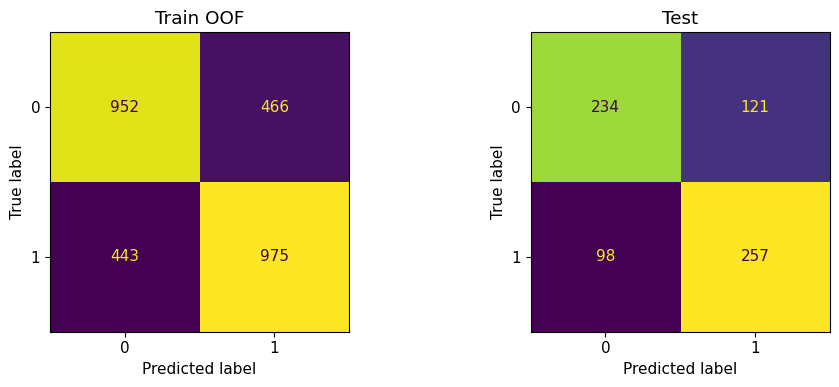

In [30]:
# ── 최종 Test set 평가 (1회만 실행)
from sklearn.model_selection import cross_val_predict

final_model = gs.best_estimator_
final_model.fit(X_train, y_train)

test_auc  = roc_auc_score(y_test, final_model.predict_proba(X_test)[:, 1])
train_auc = gs.best_score_

print(f"Train CV AUC : {train_auc:.4f}")
print(f"Test AUC     : {test_auc:.4f}")
print(f"과적합 갭    : {train_auc - test_auc:+.4f}")

# OOF Confusion Matrix (Train 기준)
y_oof = cross_val_predict(final_model, X_train, y_train, cv=skf, method='predict')
print(f"\n[Train OOF] Classification Report:")
print(classification_report(y_train, y_oof))

# Test Confusion Matrix
print(f"[Test] Classification Report:")
print(classification_report(y_test, final_model.predict(X_test)))

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
ConfusionMatrixDisplay.from_predictions(y_train, y_oof, ax=axes[0], colorbar=False)
axes[0].set_title("Train OOF")
ConfusionMatrixDisplay.from_predictions(y_test, final_model.predict(X_test), ax=axes[1], colorbar=False)
axes[1].set_title("Test")
plt.tight_layout()
plt.show()

In [31]:
# ── 최종 모델 저장
import pickle, os

final_model = gs.best_estimator_
final_model.fit(X_train, y_train)

test_auc = roc_auc_score(y_test, final_model.predict_proba(X_test)[:, 1])
print(f"=== 최종 모델 성능 ===")
print(f"ml_v14 (베이스라인)                   : 0.7852")
print(f"ml_v15 (ingredient_count 추가)        : {test_auc:.4f}")
print(f"목표                                  : 0.8000")

# 카테고리별 최적 threshold (Train OOF 기반)
CATEGORY_THRESHOLDS = {
    'skincare':  0.50,
    'cleansing': 0.50,
    'masks':     0.40,  # 긍정비율 39% → threshold 낮춤
    'suncare':   0.50,
}

save_dir = r"C:\workspace\finalproject\data\model_output"
os.makedirs(save_dir, exist_ok=True)

model_data = {
    'model':                 final_model,
    'feat_cols':             feat_cols,
    'gt_map':                gt_map,
    'new_position_targets':  new_position_targets,
    'category_spec_cols':    category_spec_cols,
    'category_thresholds':   CATEGORY_THRESHOLDS,
    'y_type':                'composite_rating_x_review',
}
save_path = os.path.join(save_dir, 'lgbm_v15.pkl')
with open(save_path, 'wb') as f:
    pickle.dump(model_data, f)

print(f"\n모델 저장 완료: {save_path}")
print(f"저장 피처 수: {len(feat_cols)}개")
print(f"\nCATEGORY_THRESHOLDS: {CATEGORY_THRESHOLDS}")

=== 최종 모델 성능 ===
ml_v14 (베이스라인)                   : 0.7852
ml_v15 (ingredient_count 추가)        : 0.7433
목표                                  : 0.8000

모델 저장 완료: C:\workspace\finalproject\data\model_output\lgbm_v15.pkl
저장 피처 수: 71개

CATEGORY_THRESHOLDS: {'skincare': 0.5, 'cleansing': 0.5, 'masks': 0.4, 'suncare': 0.5}


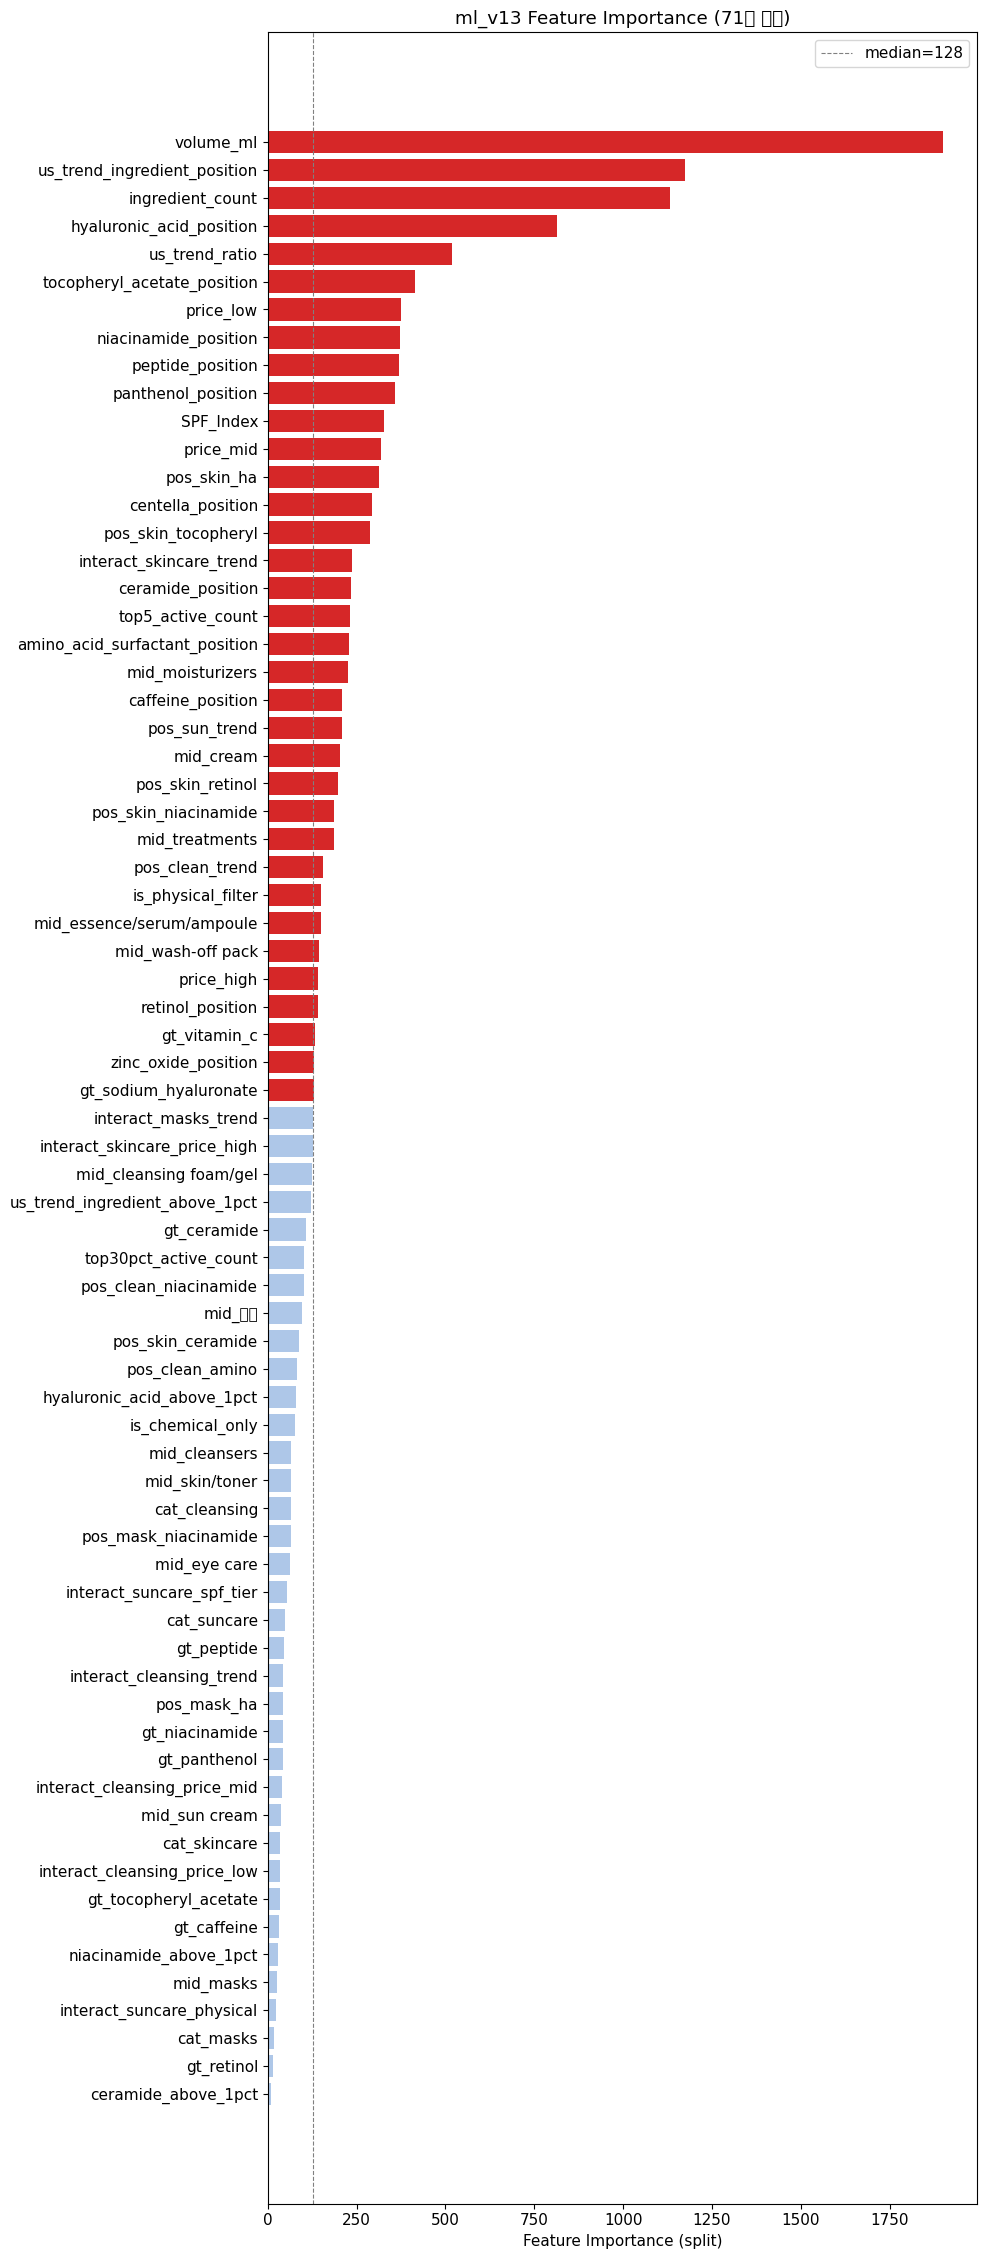


전체 피처 중요도 (내림차순):
volume_ml                         1901
us_trend_ingredient_position      1173
ingredient_count                  1132
hyaluronic_acid_position           813
us_trend_ratio                     517
tocopheryl_acetate_position        414
price_low                          376
niacinamide_position               371
peptide_position                   368
panthenol_position                 359
SPF_Index                          328
price_mid                          318
pos_skin_ha                        312
centella_position                  293
pos_skin_tocopheryl                287
interact_skincare_trend            238
ceramide_position                  234
top5_active_count                  232
amino_acid_surfactant_position     228
mid_moisturizers                   225
caffeine_position                  210
pos_sun_trend                      210
mid_cream                          204
pos_skin_retinol                   197
mid_treatments                     187
pos_sk

In [32]:
# ── 피처 Importance 시각화
imp_series = pd.Series(final_model.feature_importances_, index=feat_cols).sort_values(ascending=True)

plt.figure(figsize=(10, len(feat_cols) * 0.32))
colors = ['#d62728' if v > imp_series.median() else '#aec7e8' for v in imp_series]
plt.barh(imp_series.index, imp_series.values, color=colors)
plt.axvline(imp_series.median(), color='gray', linestyle='--', linewidth=0.8, label=f'median={imp_series.median():.0f}')
plt.xlabel('Feature Importance (split)')
plt.title(f'ml_v13 Feature Importance ({len(feat_cols)}개 피처)')
plt.legend()
plt.tight_layout()
plt.show()

print("\n전체 피처 중요도 (내림차순):")
print(imp_series.sort_values(ascending=False).to_string())

=== 카테고리별 Test 성능 ===

카테고리                 n      긍정비율      AUC       F1  신뢰도
-----------------------------------------------------------------
skincare           491     48.3%   0.7631   0.6850  ✅ 신뢰
cleansing          114     60.5%   0.6520   0.7733  ✅ 신뢰
masks               46     39.1%   0.6845   0.5161  △ 참고
suncare             59     52.5%   0.7258   0.7342  ✅ 신뢰
-----------------------------------------------------------------
전체                 710     50.0%   0.7433   0.7012


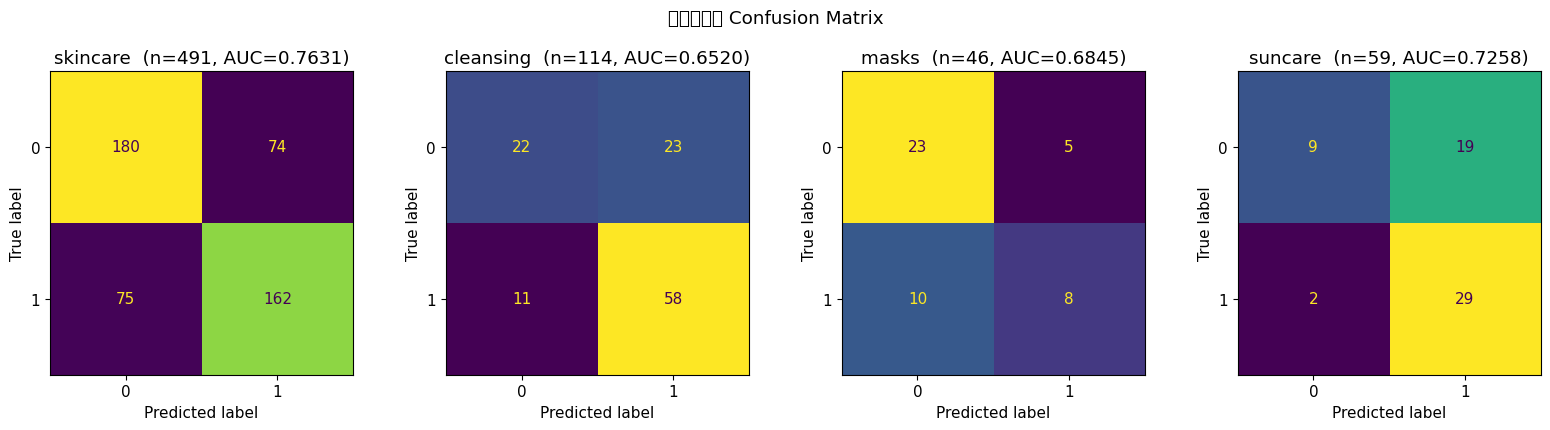

In [33]:
# ── 카테고리별 예측 성능 분석
from sklearn.metrics import f1_score
from sklearn.model_selection import train_test_split as _tts

# 동일 random_state로 test 인덱스 복원
_indices = np.arange(len(df_y))
_, _test_idx = _tts(_indices, test_size=0.2, stratify=y_all, random_state=42)

test_cats  = df_y['target_category'].iloc[_test_idx].reset_index(drop=True)
test_proba = final_model.predict_proba(X_test)[:, 1]
test_pred  = final_model.predict(X_test)

print("=== 카테고리별 Test 성능 ===\n")
print(f"{'카테고리':<16} {'n':>5}  {'긍정비율':>8}  {'AUC':>7}  {'F1':>7}  신뢰도")
print("-" * 65)

for cat in ['skincare', 'cleansing', 'masks', 'suncare']:
    mask     = (test_cats == cat).values
    n        = mask.sum()
    pos_rate = y_test[mask].mean() if n > 0 else 0

    if n == 0:
        continue
    if len(np.unique(y_test[mask])) < 2 or n < 15:
        print(f"{cat:<16} {n:>5}  {pos_rate:>8.1%}  {'N/A':>7}  {'N/A':>7}  ⚠ 샘플 부족")
        continue

    cat_auc = roc_auc_score(y_test[mask], test_proba[mask])
    cat_f1  = f1_score(y_test[mask], test_pred[mask])
    trust   = "✅ 신뢰" if n >= 50 else "△ 참고"
    print(f"{cat:<16} {n:>5}  {pos_rate:>8.1%}  {cat_auc:>7.4f}  {cat_f1:>7.4f}  {trust}")

print("-" * 65)
print(f"{'전체':<16} {len(y_test):>5}  {y_test.mean():>8.1%}  "
      f"{roc_auc_score(y_test, test_proba):>7.4f}  {f1_score(y_test, test_pred):>7.4f}")

# 카테고리별 Confusion Matrix
cats_to_plot = [c for c in ['skincare', 'cleansing', 'masks', 'suncare']
                if (test_cats == c).sum() >= 15 and len(np.unique(y_test[(test_cats == c).values])) >= 2]
fig, axes = plt.subplots(1, len(cats_to_plot), figsize=(4 * len(cats_to_plot), 4))
if len(cats_to_plot) == 1:
    axes = [axes]
for ax, cat in zip(axes, cats_to_plot):
    mask = (test_cats == cat).values
    auc  = roc_auc_score(y_test[mask], test_proba[mask])
    ConfusionMatrixDisplay.from_predictions(
        y_test[mask], test_pred[mask], ax=ax, colorbar=False
    )
    ax.set_title(f"{cat}  (n={mask.sum()}, AUC={auc:.4f})")
plt.suptitle("카테고리별 Confusion Matrix", y=1.02)
plt.tight_layout()
plt.show()

In [34]:
# ── Masks 카테고리 Threshold 최적화
# Train OOF 확률로 최적 threshold 탐색 → Test에 적용 (데이터 누수 없음)
from sklearn.model_selection import train_test_split as _tts

# OOF 확률 예측 (train 기준)
oof_proba = cross_val_predict(final_model, X_train, y_train, cv=skf, method='predict_proba')[:, 1]

# train/test 인덱스 복원
_indices_all = np.arange(len(df_y))
_train_idx2, _test_idx2 = _tts(_indices_all, test_size=0.2, stratify=y_all, random_state=42)
train_cats = df_y['target_category'].iloc[_train_idx2].reset_index(drop=True)

# train masks OOF로 최적 threshold 탐색
masks_train_mask = (train_cats == 'masks').values
oof_masks_proba  = oof_proba[masks_train_mask]
y_masks_train    = y_train[masks_train_mask]

print(f"Masks Train 샘플: {masks_train_mask.sum()}개  (긍정비율: {y_masks_train.mean():.1%})")
print(f"\nThreshold별 Train OOF F1:")
print(f"  {'Threshold':>10}  {'F1':>7}  {'Precision':>10}  {'Recall':>8}")
print(f"  {'-'*42}")

best_th, best_f1 = 0.5, 0.0
for th in np.arange(0.25, 0.75, 0.05):
    pred = (oof_masks_proba >= th).astype(int)
    if len(np.unique(pred)) < 2:
        continue
    f1   = f1_score(y_masks_train, pred)
    prec = (pred[y_masks_train == 1] == 1).mean() if pred.sum() > 0 else 0
    rec  = (pred[y_masks_train == 1] == 1).mean()
    from sklearn.metrics import precision_score, recall_score
    prec = precision_score(y_masks_train, pred, zero_division=0)
    rec  = recall_score(y_masks_train, pred)
    marker = " ◀ best" if f1 > best_f1 else ""
    print(f"  {th:>10.2f}  {f1:>7.4f}  {prec:>10.4f}  {rec:>8.4f}{marker}")
    if f1 > best_f1:
        best_f1, best_th = f1, th

# test masks에 최적 threshold 적용
masks_test_mask  = (test_cats == 'masks').values
masks_test_proba = test_proba[masks_test_mask]
y_masks_test     = y_test[masks_test_mask]

f1_default = f1_score(y_masks_test, (masks_test_proba >= 0.50).astype(int))
f1_tuned   = f1_score(y_masks_test, (masks_test_proba >= best_th).astype(int))
auc_masks  = roc_auc_score(y_masks_test, masks_test_proba)

print(f"\n=== Test 결과 ===")
print(f"  최적 threshold (Train OOF): {best_th:.2f}")
print(f"  Test AUC          : {auc_masks:.4f}  (threshold 무관)")
print(f"  Test F1 (th=0.50) : {f1_default:.4f}")
print(f"  Test F1 (th={best_th:.2f}) : {f1_tuned:.4f}  ({f1_tuned - f1_default:+.4f})")

Masks Train 샘플: 197개  (긍정비율: 34.5%)

Threshold별 Train OOF F1:
   Threshold       F1   Precision    Recall
  ------------------------------------------
        0.25   0.6171      0.5047    0.7941 ◀ best
        0.30   0.6420      0.5532    0.7647 ◀ best
        0.35   0.6846      0.6296    0.7500 ◀ best
        0.40   0.6619      0.6479    0.6765
        0.45   0.6202      0.6557    0.5882
        0.50   0.5950      0.6792    0.5294
        0.55   0.5586      0.7209    0.4559
        0.60   0.4400      0.6875    0.3235
        0.65   0.3556      0.7273    0.2353
        0.70   0.3218      0.7368    0.2059

=== Test 결과 ===
  최적 threshold (Train OOF): 0.35
  Test AUC          : 0.6845  (threshold 무관)
  Test F1 (th=0.50) : 0.5161
  Test F1 (th=0.35) : 0.5116  (-0.0045)


In [35]:
# ml_v16 노트북에서, 피처 생성 완료 후 바로 다음 셀에:

print("=== volume_ml과 target 상관관계 ===")
corr = df_y[['volume_ml', 'target']].corr()
print(corr)
print(f"\n피어슨 상관계수: {df_y['volume_ml'].corr(df_y['target']):.4f}")

print("\n=== 그룹별 volume_ml 통계 ===")
print(f"긍정(target=1) volume_ml: mean={df_y[df_y['target']==1]['volume_ml'].mean():.1f}, median={df_y[df_y['target']==1]['volume_ml'].median():.1f}")
print(f"부정(target=0) volume_ml: mean={df_y[df_y['target']==0]['volume_ml'].mean():.1f}, median={df_y[df_y['target']==0]['volume_ml'].median():.1f}")

print("\n=== 주요 피처들의 target 상관계수 ===")
key_features = ['volume_ml', 'ingredient_count', 'us_trend_ratio', 'price_low', '공급가(USD)']
for feat in key_features:
    if feat in df_y.columns:
        corr_val = df_y[feat].corr(df_y['target'])
        print(f"{feat}: {corr_val:.4f}")

=== volume_ml과 target 상관관계 ===
           volume_ml    target
volume_ml   1.000000  0.040683
target      0.040683  1.000000

피어슨 상관계수: 0.0407

=== 그룹별 volume_ml 통계 ===
긍정(target=1) volume_ml: mean=84.0, median=50.3
부정(target=0) volume_ml: mean=74.7, median=50.3

=== 주요 피처들의 target 상관계수 ===
volume_ml: 0.0407
ingredient_count: 0.0463
us_trend_ratio: 0.0329
price_low: 0.0186
공급가(USD): -0.0965
